## Analysis

### Load CSV

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path configuration
BASE_DIR = './'
SUMMARY_PATH = os.path.join(BASE_DIR, "summary.csv")

In [5]:
if not os.path.exists(SUMMARY_PATH):
    raise FileNotFoundError("summary.csv not found.")

df = pd.read_csv(SUMMARY_PATH)

if df.empty:
    raise ValueError("summary.csv is empty.")

print("Loaded dataframe shape:", df.shape)
df.head()

Loaded dataframe shape: (7, 30)


,experiment_name,machine_name,request_throughput_avg,request_latency_avg_ms,request_latency_std_ms,time_to_first_token_avg_ms,time_to_first_token_std_ms,inter_token_latency_avg_ms,inter_token_latency_std_ms,time_to_second_token_avg_ms,...,ttst_ms_p90,ttst_ms_p99,inter_token_latency_ms_p50,inter_token_latency_ms_p90,inter_token_latency_ms_p99,input_sequence_length_avg,input_sequence_length_std,output_sequence_length_avg,output_sequence_length_std,avg_concurrency
0,N2_poti_PP_long_r1_780376,"poti[1,5]",0.056931,17561.504580,7.605487,397.261167,0.468119,33.888200,0.291482,33.458546,...,33.662829,33.726960,33.937505,34.155432,34.615519,1024.0,0.0,507.533333,4.400104,0.999788
1,N2_poti_TP_short_r1_780378,"poti[1,5]",0.241817,4133.885852,12.290393,555.136192,0.780071,28.186573,0.102223,28.177835,...,28.488397,29.108162,28.127366,28.330452,28.360484,128.0,0.0,127.966667,0.182574,0.999643
2,N2_poti_PP_short_r1_780413,"poti[1,3]",0.231840,4311.656248,2.844926,78.803583,0.256412,33.320868,0.051373,33.196647,...,33.329718,33.402316,33.326377,33.357196,33.380847,128.0,0.0,128.033333,0.182574,0.999613
3,N1_tupi_none_short_r1_780423,tupi6,0.471978,2117.053485,0.707969,25.959997,0.313330,16.478575,0.070244,16.331817,...,16.420658,16.480939,16.465979,16.473827,16.745563,128.0,0.0,127.900000,0.547723,0.999203
4,N2_poti_TP_long_r1_780377,"poti[1,5]",0.054236,18434.523031,51.408432,3861.769976,3.906470,28.783393,0.360213,28.279900,...,28.561795,28.696231,28.792462,29.037345,29.962845,1024.0,0.0,507.366667,6.445974,0.999823


### Analysis

In [6]:
experiment_name_mapping = {
    'N1_tupi_none_long_r1_780424': 'tupi (N1) Long Seq',
    'N1_tupi_none_short_r1_780423': 'tupi (N1) Short Seq',
    'N2_poti_PP_long_r1_780376': 'poti (N2) PP Long Seq',
    'N2_poti_PP_short_r1_780413': 'poti (N2) PP Short Seq',
    'N2_poti_TP_short_r1_780378': 'poti (N2) TP Short Seq',
    'N2_poti_TP_long_r1_780377': 'poti (N2) TP Long Seq',
    'infer_vllm_778989': 'tupi2'
}

df['display_name'] = df['experiment_name'].map(experiment_name_mapping)

In [7]:
metrics_to_plot = [
    'request_throughput_avg',
    'request_latency_avg_ms',
    'time_to_first_token_avg_ms',
    'input_sequence_length_avg',
    'output_sequence_length_avg',
    'output_token_throughput_avg',
    'inter_token_latency_avg_ms',
]

In [8]:
# Identify communication experiments (PP / TP)
df['is_communication'] = df['display_name'].str.contains('PP|TP', case=False, na=False)

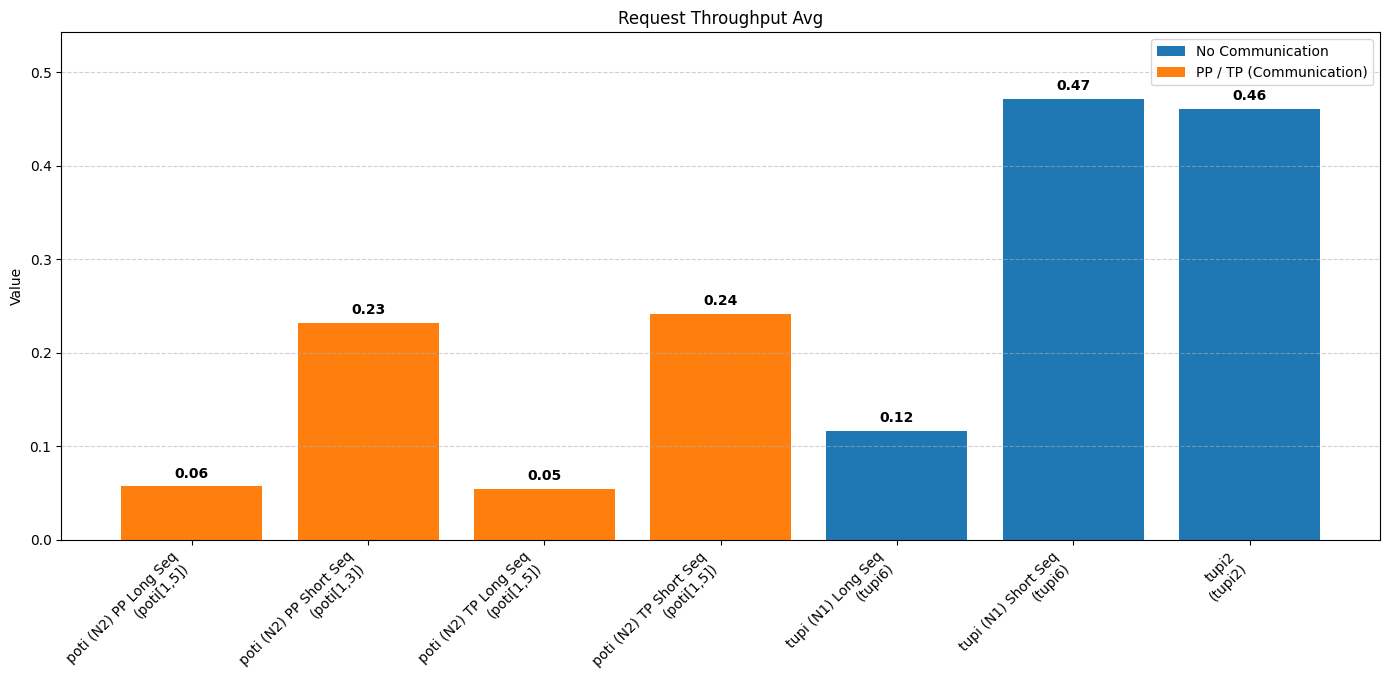

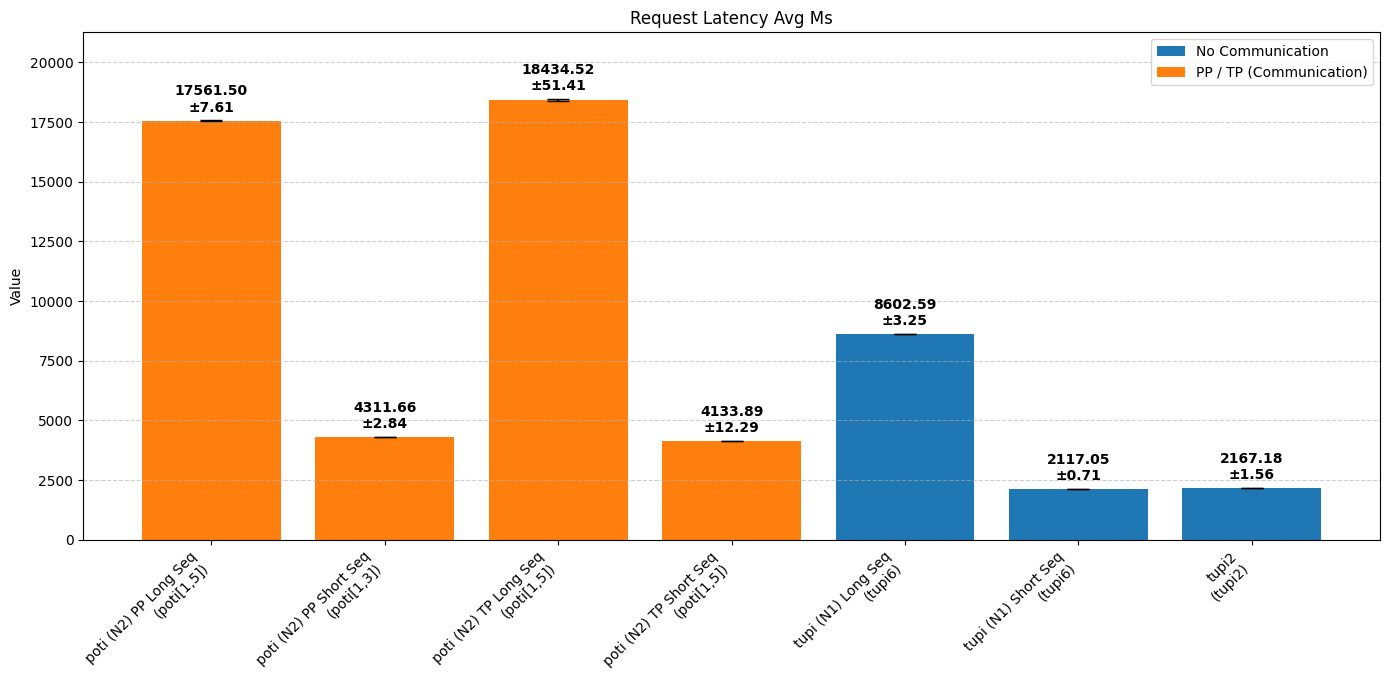

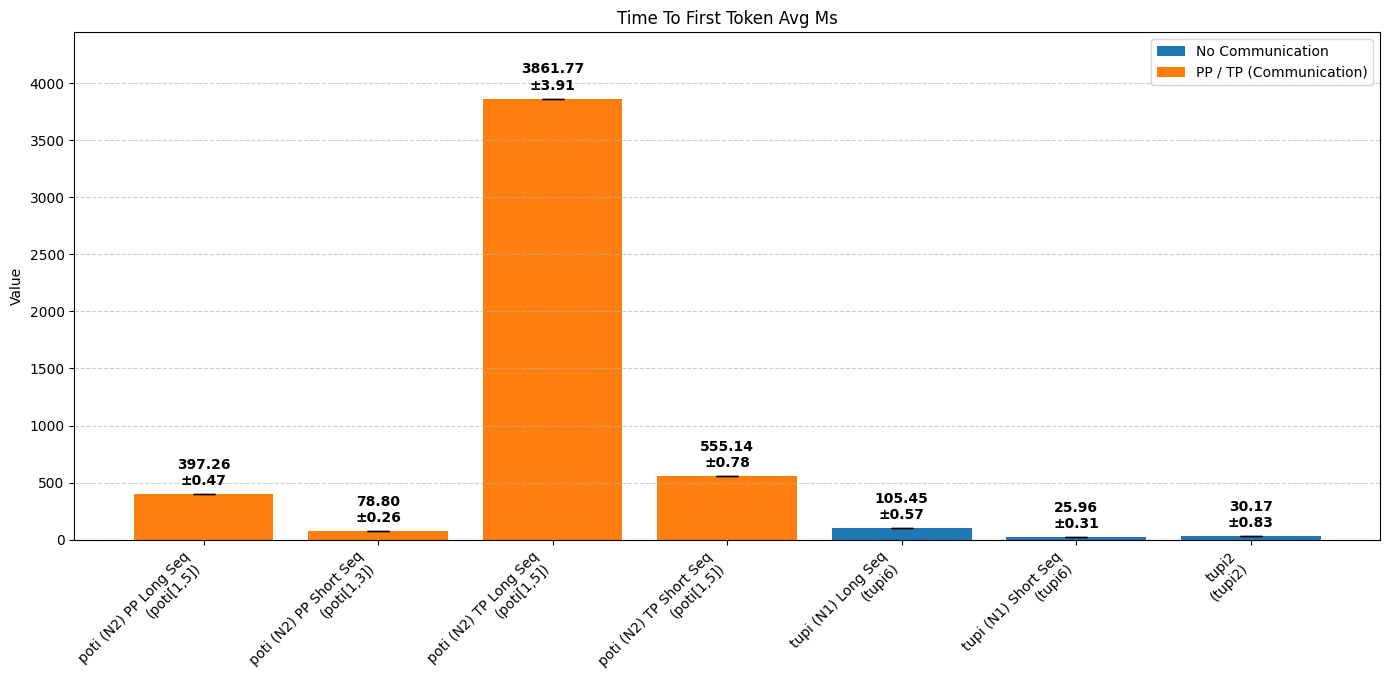

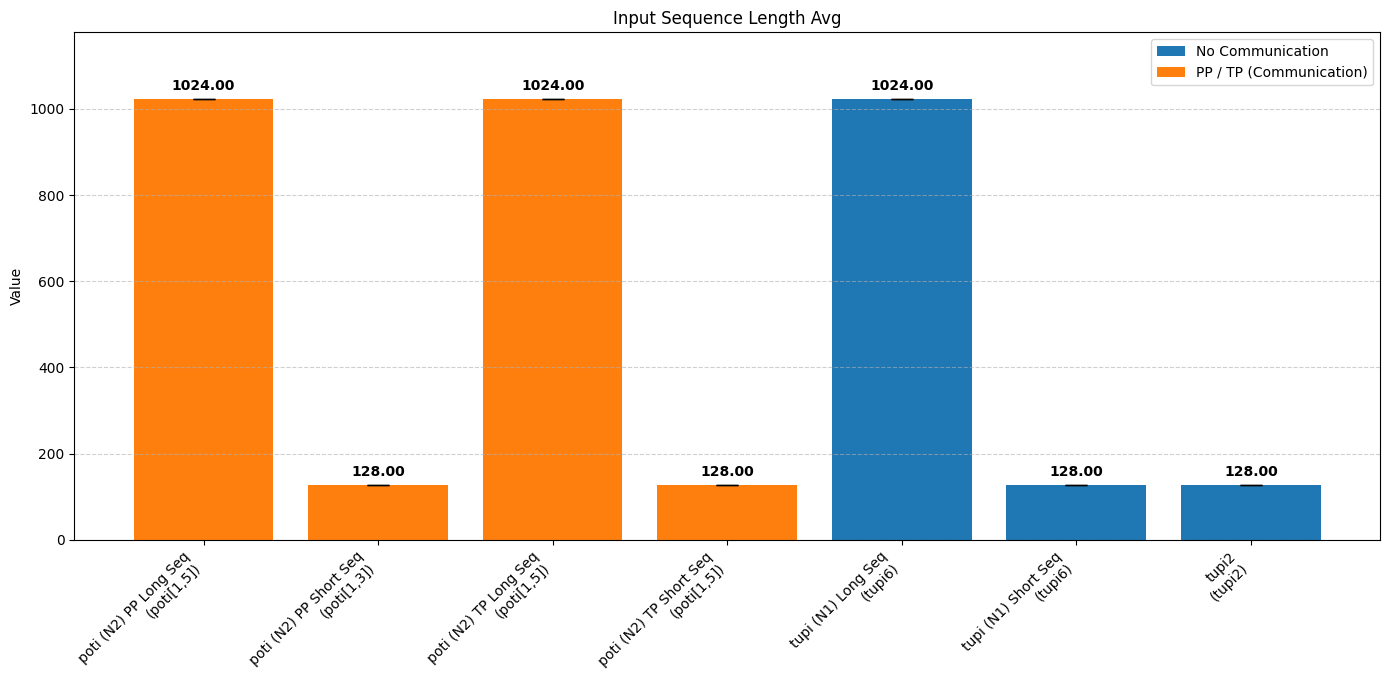

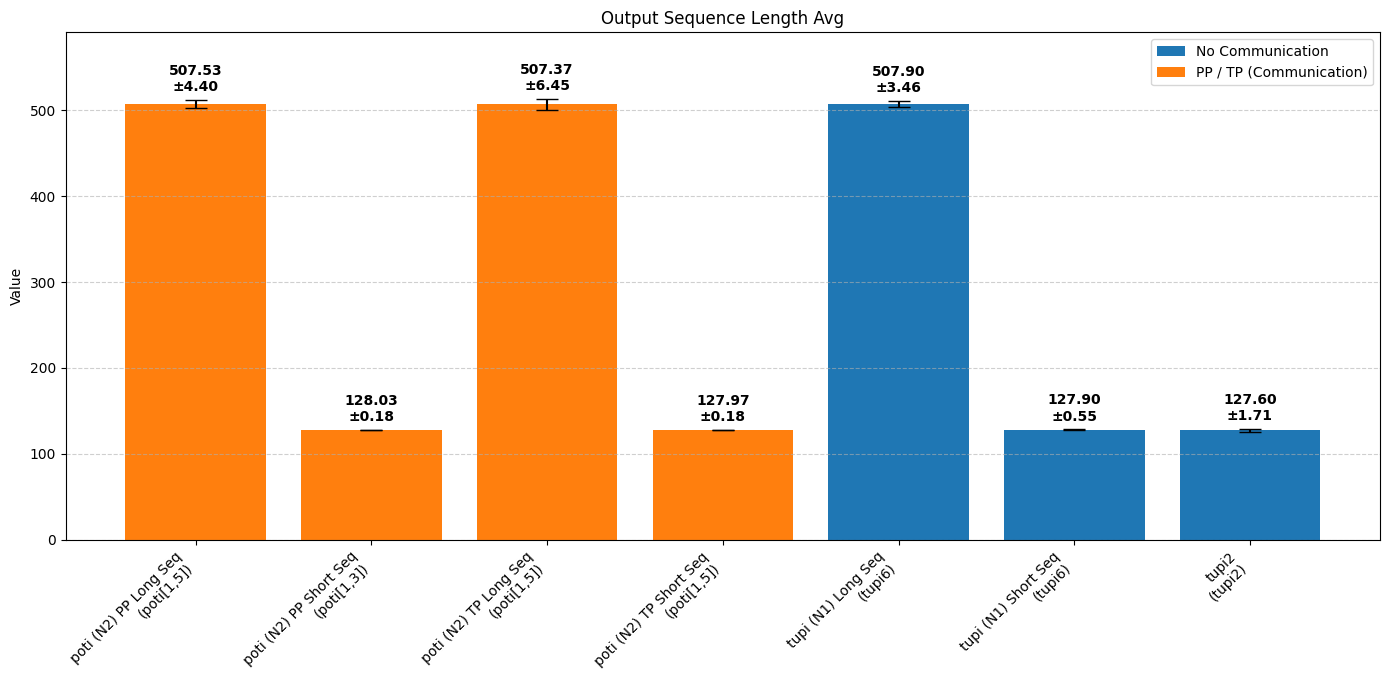

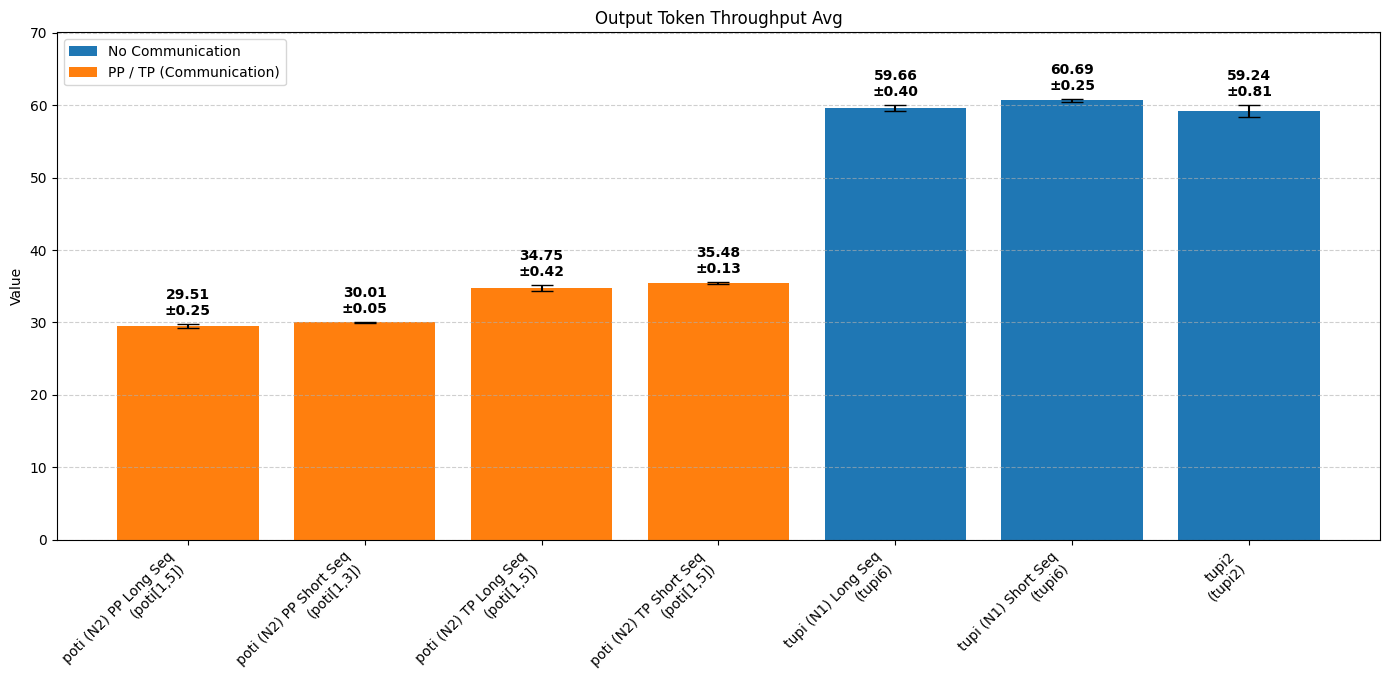

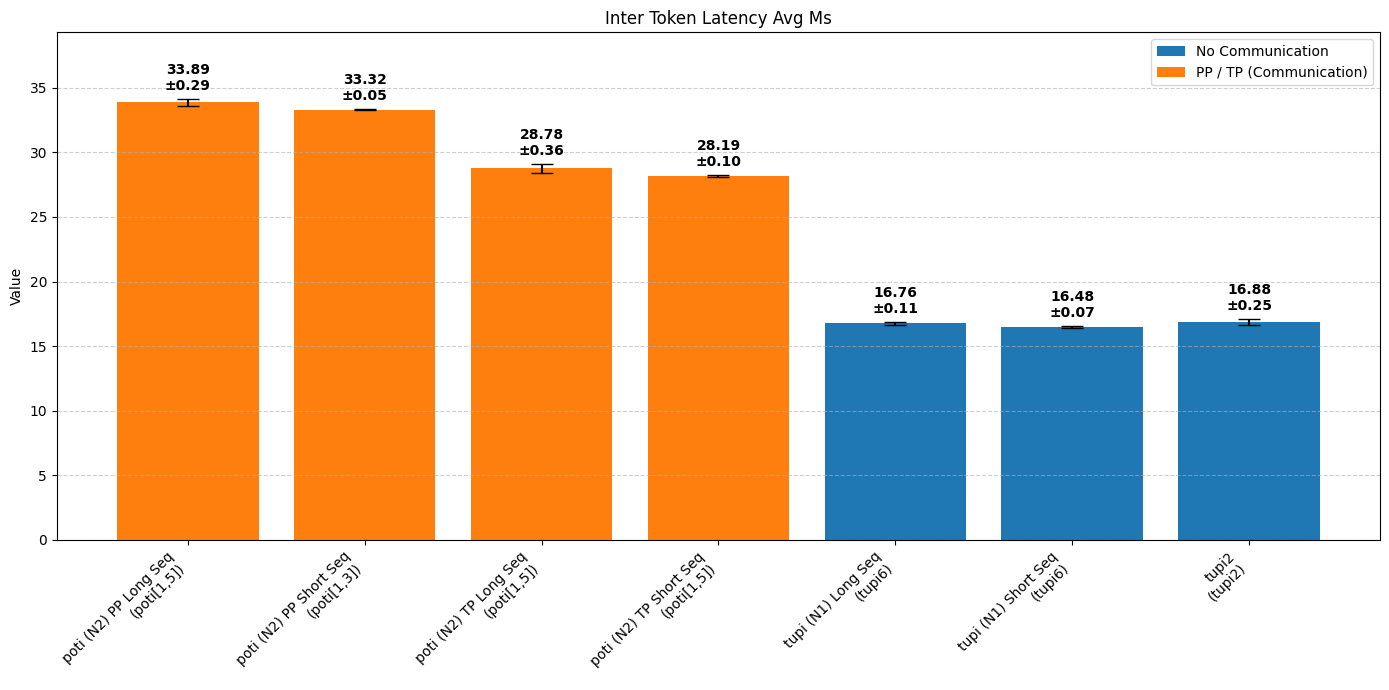

In [11]:
for avg_col in metrics_to_plot:

    # Handle std naming properly
    if avg_col.endswith('_avg_ms'):
        std_col = avg_col.replace('_avg_ms', '_std_ms')
    else:
        std_col = avg_col.replace('_avg', '_std')

    if avg_col not in df.columns:
        print(f"Skipping {avg_col}: column not found.")
        continue

    plot_df = df[['display_name', 'machine_name', 'is_communication', avg_col]].copy()

    if std_col in df.columns:
        plot_df[std_col] = df[std_col]

    plot_df = plot_df.dropna(subset=[avg_col])

    if plot_df.empty:
        continue

    plot_df = plot_df.sort_values('display_name').reset_index(drop=True)

    x = np.arange(len(plot_df))
    y = plot_df[avg_col].values

    has_std = std_col in plot_df.columns and plot_df[std_col].notna().any()
    yerr = plot_df[std_col].values if has_std else None 

    # ===== COLOR LOGIC =====
    colors = [
        'tab:blue' if not is_comm else 'tab:orange'
        for is_comm in plot_df['is_communication']
    ]

    plt.figure(figsize=(14, 7))

    bars = plt.bar(
        x,
        y,
        yerr=yerr,
        capsize=8 if has_std else 0,
        color=colors
    )

    # ===== LABELS =====
    offset = 0.02 * np.nanmax(y)

    max_height = 0  # track highest point (including std)

    for i, (xi, yi) in enumerate(zip(x, y)):
        label = f"{yi:.2f}"

        if has_std:
            std_val = yerr[i]
            if not np.isnan(std_val) and std_val > 0:
                label += f"\n±{std_val:.2f}"
                y_pos = yi + std_val + offset
                max_height = max(max_height, yi + std_val)
            else:
                y_pos = yi + offset
                max_height = max(max_height, yi)
        else:
            y_pos = yi + offset
            max_height = max(max_height, yi)

        plt.text(
            xi,
            y_pos,
            label,
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    # ===== ADD HEADROOM =====
    plt.ylim(0, max_height * 1.15)  # 15% extra space

    # ===== X LABELS =====
    labels = [
        f"{name}\n({machine})"
        for name, machine in zip(plot_df['display_name'], plot_df['machine_name'])
    ]

    plt.xticks(x, labels, rotation=45, ha='right')

    # ===== LEGEND =====
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='tab:blue', label='No Communication'),
        Patch(facecolor='tab:orange', label='PP / TP (Communication)')
    ]
    plt.legend(handles=legend_elements)

    # ===== FINAL =====
    plt.title(avg_col.replace('_', ' ').title())
    plt.ylabel("Value")
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()